# Задание 2. Воспроизведение метрики AUC of pose error на ALTO

**Опорная статья.** S. Li, Z. Gu, J. Zhang, Q. Guo, X. Jiang, J. Cheng.
*SURE: Semi-dense Uncertainty-REfined Feature Matching*.
arXiv:[2603.04869](https://arxiv.org/abs/2603.04869), 5 марта 2026;
принята на ICRA 2026. Код: github.com/LSC-ALAN/SURE

Ключевая метрика статьи — **AUC ошибки относительной позы при порогах
5°, 10°, 20°**. Это же стандарт оценки в SuperGlue, LoFTR, LightGlue, RoMa
и во всех просмотренных публикациях 2026 года по feature matching.

Статья выбрана по трём причинам:

1. её протокол выписан явно (LO-RANSAC для MegaDepth, инлайер-порог 0.5,
   кадры 832×832) — этого нет у большинства публикаций, а без протокола
   метрика невоспроизводима;
2. в таблице есть строка SuperPoint + LightGlue — прямой аналог нашего
   подхода (c), то есть сравнение идёт с тем же методом, а не «через
   один» с чужим;
3. метрика вычислима при наличии только GT-поз, без GT-глубин и
   GT-гомографий, которых у нас нет.

**Второй источник для сравнения.** H. Zhang и др. *Efficient image matching
for UAV visual navigation via DALGlue*. Scientific Reports **15**, 37684 (2025).
Домен ближе к нашему (аэросъёмка с БПЛА), но протокол не выписан. Он нужен нам
не столько для сравнения, сколько как второй замер того же самого
SuperPoint + LightGlue: 47.83 против 58.8 у SURE на одном и том же
MegaDepth-1500. Разброс в 11 пунктов AUC@5 для неизменного метода — отдельный
предмет измерения в §6.

**Что делается в этом ноутбуке.**

1. Выписывается определение метрики формулами и проверяется на данных
   с заранее известным ответом (§1).
2. Из телеметрии ALTO строятся истинные относительные позы; отдельно решается
   нетривиальная задача — калибровка постоянного разворота между системой
   координат кватерниона и системой OpenCV (§2). Без неё метрика измеряет
   не ошибку метода, а ошибку соглашения об осях.
3. Метрика считается для трёх подходов задания 1 при **одинаковом** оценщике
   позы — эссенциальная матрица + RANSAC, как в статье (§3).
4. Расхождение с числами статьи объясняется тремя измеряемыми факторами:
   отношением база/глубина (§4), протоколом RANSAC и разрешением кадра (§6).

**Зачем это нужно проекту.** В задании 1 все метрики трансляционные
(ATE, RPE, drift), ошибка вращения не измерялась нигде, хотя весь анализ
показал, что разваливается именно вращение. AUC ошибки позы закрывает
этот пробел: она разделяет вклад вращения и направления трансляции
и не зависит от неизвестного монокулярного масштаба.

In [1]:
# --- окружение -------------------------------------------------------------
# ВАЖНО: OpenCV строго 4.x (в 5.0 нет AKAZE_create/logPolar), и он должен быть
# contrib-сборкой. Установка LightGlue молча перетирает opencv-contrib-python.
import sys, os, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt


def find_project_root() -> Path:
    # Корень проекта -- каталог, в котором лежит src/vo_core.py. Ищется вверх
    # от рабочего каталога, поэтому ноутбук работает и из notebooks/, и из
    # корня. Поддержана также плоская раскладка, когда модули лежат рядом
    # с ноутбуком. Это НЕ каталог с данными -- тот берётся из
    # alto_data.DEFAULT_ROOT (см. следующую ячейку).
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "src" / "vo_core.py").exists() or (d / "vo_core.py").exists():
            return d
    raise FileNotFoundError(
        "не найден vo_core.py ни в src/, ни рядом с ноутбуком. "
        "Запускайте ноутбук из каталога проекта либо задайте ROOT вручную.")


ROOT = find_project_root()
SRC_DIR = ROOT / "src" if (ROOT / "src" / "vo_core.py").exists() else ROOT
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import vo_core as vc
import alto_data as ad
import pose_auc as pa

RESULTS_DIR = ROOT / "results"          # таблицы и журнал выполнения
FIG_DIR = ROOT / "report" / "figures"   # рисунки отчёта
REPORT_DIR = ROOT / "report"
for d in (RESULTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# по желанию: дублирование всего вывода в markdown-файл
try:
    from runlog import start_log, finish_log
    start_log(RESULTS_DIR / "log_task2.md")
except Exception as e:
    print("runlog недоступен:", e)

print("корень проекта:", ROOT)
print("модули:        ", SRC_DIR)
print("результаты:    ", RESULTS_DIR)
print("рисунки:       ", FIG_DIR)
print("OpenCV:", cv2.__version__, "| numpy:", np.__version__)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

[runlog] пишу в /root/submission/results/log_task2.md
корень проекта: /root/submission
модули:         /root/submission/src
результаты:     /root/submission/results
рисунки:        /root/submission/report/figures
OpenCV: 4.13.0 | numpy: 2.3.0


данные:  /mnt/d/deepsound -> ['Test', 'Train', 'Val']
кэш:     /root/alto_cache
[[324.07   0.   250.  ]
 [  0.   324.07 250.  ]
 [  0.     0.     1.  ]]

Допущения при воспроизведении метрики (для раздела Discussions):
 1. Площадь под кривой считается по канонической реализации SuperGlue
    (кусочно-линейная интерполяция ЭФР, нормировка на порог). В статье
    формула AUC не выписана.
 2. Отказ оценщика (E не найдена, < 8 инлаеров) кодируется ошибкой 180 deg,
    то есть пара учитывается как полностью проваленная, а не выбрасывается.
    Это соглашение SuperGlue; в статье поведение при отказе не описано.
 3. err_t сворачивается как min(err_t, 180 - err_t): знак трансляции из
    эссенциальной матрицы определён с точностью до направления. Функция
    умеет считать и без свёртки (fold_translation=False) -- разница
    показывает, сколько пар развёрнуты на 180 deg.
 4. GT-поза берётся из телеметрии (UTM + кватернион), а не из SfM-реконструкции,
    как в MegaDepth. Точность GT ограничена

/root/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


[learned] используется SuperPoint+LightGlue
  (a) SIFT+BF                  init_shift=False
  (b) ORB+LK                   init_shift=True
  (c) SuperPoint+LightGlue     init_shift=False
пар в выборке: 300 (сплит Val, stride 20)
(a) SIFT+BF                   300 пар за  26.6 с, отказов 0.0 %
(b) ORB+LK                    300 пар за  18.1 с, отказов 0.0 %


/root/submission/src/learned_frontends.py:55: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  t = self.torch.from_numpy(np.ascontiguousarray(img)).float()[None, None] / 255.0


(c) SuperPoint+LightGlue      300 пар за  37.3 с, отказов 0.0 %
stride   1 готов
stride   2 готов
stride   5 готов
stride  10 готов
stride  20 готов
stride  40 готов
разброс AUC@5 для SP+SuperGlue между публикациями: 34.18 … 57.60 (23.4 пункта)
две последние строки -- ОДНА публикация, отличается только разрешение
[калибровка] кандидат #0: z_down=-0.999, согласованность=0.997, psi0=-0.34 deg
(c) SuperPoint+LightGlue готов

размах AUC@20 только от выбора протокола: 78.20 … 82.40 (4.2 пункта)
500 px готово
832 px готово
1200 px готово
записано note_values.json: 34 полей
[build_note] готово: /root/submission/Research_Note.pdf

[runlog] готово: /root/submission/results/log_task2.md


In [2]:
# --- константы, откалиброванные в задании 1 --------------------------------
GSD      = 0.6010            # м/пиксель
F_EFF    = 324.07            # px
AGL      = 194.8             # м = GSD * F_EFF
K        = np.array([[F_EFF, 0.0, 250.0],
                     [0.0, F_EFF, 250.0],
                     [0.0, 0.0, 1.0]])
STRIDE   = 20                # база 54.8 м, база/глубина ~ 0.28
N_PAIRS  = 300               # пар на прогон

# Протокол опорной статьи (SURE, ICRA 2026): LO-RANSAC, инлайер-порог 0.5 px.
# В OpenCV точного LO-RANSAC нет, ближайший аналог -- USAC_ACCURATE.
# Насколько это расхождение влияет на метрику, измеряется в §6.
RANSAC_PX = 0.5
RANSAC_METHOD = "lo"

DATA_ROOT = ad.DEFAULT_ROOT           # /mnt/d/deepsound -- каталог с Train/Val/Test
CACHE_DIR = Path.home() / "alto_cache"   # обязательно ext4, не /mnt/d

# DATA_ROOT и ROOT -- разные вещи: первый содержит данные (Train/Val/Test),
# второй -- каталог проекта с кодом и отчётом. Если данные лежат не там, правится DEFAULT_ROOT
# в alto_data.py либо DATA_ROOT прямо здесь.
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"каталог с данными не найден: {DATA_ROOT}\n"
        f"внутри должны лежать подкаталоги Train/ Val/ Test/. "
        f"Задайте DATA_ROOT = Path('...') вручную.")
print("данные: ", DATA_ROOT, "->", sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir()))
print("кэш:    ", CACHE_DIR)
print(K)

## 1. Метрика статьи

### 1.1. Определение

Статья оценивает качество сопоставления через точность **относительной позы**,
восстановленной из соответствий: по матчам считается эссенциальная матрица
с RANSAC, из неё — вращение $R_{\text{est}}$ и направление трансляции
$t_{\text{est}}$. Ошибка позы — максимум из двух угловых ошибок:

$$e_R = \arccos\!\left(\frac{\operatorname{tr}(R_{\text{est}}^{\top} R_{\text{gt}}) - 1}{2}\right),
\qquad
e_t = \arccos\!\left(\frac{\langle t_{\text{est}},\, t_{\text{gt}}\rangle}{\lVert t_{\text{est}}\rVert\,\lVert t_{\text{gt}}\rVert}\right),$$

$$e = \max(e_R,\, e_t) \quad [\text{градусы}].$$

Длина трансляции в метрику не входит — это принципиально для монокулярной
постановки, где масштаб неизвестен. Знак $t$ из эссенциальной матрицы определён
неоднозначно, поэтому каноническая реализация сворачивает
$e_t \leftarrow \min(e_t,\ 180^\circ - e_t)$.

Пусть $F(x)$ — доля пар с $e \le x$ (эмпирическая функция распределения). Тогда

$$\mathrm{AUC}@X = \frac{1}{X}\int_0^X F(x)\,dx \in [0, 1].$$

Смысл: это средняя по порогам доля успешных пар. Значение 1 — все позы точны,
0.5 при $X = 20°$ соответствует равномерно распределённой ошибке на $[0°, 20°]$.

### 1.2. Что в определении статьи не дописано

Статья говорит, что следует протоколу SuperGlue/LoFTR, но не выписывает ни
формулу площади, ни правило обработки отказов. Более того, раздел «Evaluation
metrics» смешивает две разные постановки: сначала говорится об оценке
**гомографий** решателями RANSAC и DLT, затем — о **позах** и формуле Родрига
для ошибки вращения. Пороги 5°/10°/20° при этом угловые, то есть речь всё-таки
о позе. Мы воспроизводим каноническую реализацию SuperGlue, на которую
статья ссылается; все сделанные допущения перечислены ниже и вынесены
в раздел Discussions отчёта.

In [3]:
print(pa.ASSUMPTIONS)

In [4]:
# --- самопроверка метрики на данных с известным ответом ---------------------
# A. аналитические свойства AUC;
# B. rel_pose_error на паре с точным относительным поворотом 3 deg;
# C. полный путь "надирная сцена -> матчи с 20 % выбросов -> E -> ошибка позы".
synth = pa.synthetic_check()

## 2. Истинные относительные позы из телеметрии ALTO

### 2.1. Почему это не тривиально

В MegaDepth GT-позы приходят из SfM-реконструкции и сразу выражены в системе
координат камеры. У нас есть позиция в UTM 17N и кватернион относительно ECEF,
а система координат этого кватerniона нам неизвестна: производитель мог
использовать любую конвенцию осей, а камера физически закреплена под каким-то
углом к носу носителя.

Пусть точка мира в локальном ENU связана с точкой в системе OpenCV
(x вправо, y вниз, z вперёд) как

$$p_{\text{enu}} = Q_i\, P\, p_{\text{cv}} + c_i,$$

где $Q_i$ — матрица кватернионa, $c_i$ — центр камеры, а $P$ — **постоянный**
разворот, который и требуется найти. Тогда относительная поза в конвенции
`cv2.recoverPose` ($p_1 = R p_0 + t$):

$$R = P^{\top} Q_1^{\top} Q_0 P, \qquad t = P^{\top} Q_1^{\top} (c_0 - c_1).$$

Важно: в относительной позе $P$ **не сокращается**, а входит сопряжением.
Ошибка вращения от этого меняется слабо (сопряжение сохраняет угол поворота,
но не ось), а ошибка направления трансляции — катастрофически: разворот
крепления на $\psi_0$ добавляется к $e_t$ целиком. Синтетический тест
`test_pose_auc.py` показывает, что неучтённый $\psi_0 = 17°$ обнуляет AUC@5.

### 2.2. Как оценивается $P$ без подглядывания в оцениваемый пайплайн

1. Перебираются 24 разворота «перестановка осей + знаки». Отбираются те,
   при которых ось $z$ камеры смотрит вниз (надир): третий столбец $Q_iP$
   близок к $(0,0,-1)$.
2. Для каждого кандидата предсказывается направление сдвига сцены в кадре:
   у почти надирной камеры сдвиг точки в пикселях сонаправлен с $(t_x, t_y)$.
3. Предсказание сравнивается с **измеренным** сдвигом. Измеритель —
   2D-подобие (ORB + `estimateAffinePartial2D`), то есть инструмент, а не один
   из трёх сравниваемых подходов; оценщик позы (эссенциальная матрица)
   в калибровке не участвует вообще.
4. Остаточный поворот вокруг оптической оси доводится непрерывной поправкой
   $\psi_0$ — крепление камеры не обязано быть кратным 90°.

In [5]:
# --- загрузка сплита и кэша ------------------------------------------------
# Чтение тысяч png через /mnt/d (drvfs) даёт ~40 кадр/с; кэш в один .npy на ext4
# ускоряет на три порядка. Val ~0.4 ГБ, Train ~2.6 ГБ.
SPLIT_NAME = "Val"

split = ad.AltoSplit(DATA_ROOT, SPLIT_NAME, cache_dir=CACHE_DIR)
split.build_gray_cache()
print(split)
print(f"шаг между кадрами: медиана {np.median(split.step_m()):.2f} м, "
      f"база при stride={STRIDE}: {STRIDE * np.median(split.step_m()):.1f} м")

In [6]:
# --- центры камеры в локальном ENU и матрицы кватернионов -------------------
# UTM 17N локально совпадает с ENU с точностью до масштабного искажения
# проекции (< 0.1 % в центре зоны) -- для угловых метрик это несущественно.
xy = split.xy
alt = split.alt
centers = np.c_[xy[:, 0] - xy[0, 0], xy[:, 1] - xy[0, 1], alt - alt[0]]

def nadir_score(Q):
    "насколько хорошо какая-нибудь перестановка осей делает z камеры направленной вниз"
    return min(float(np.median((Q @ P)[:, 2, 2])) for P in pa.signed_permutations())

Q_false = ad.cam_rotations_enu(split, invert=False)
Q_true  = ad.cam_rotations_enu(split, invert=True)
s_false, s_true = nadir_score(Q_false), nadir_score(Q_true)
print(f"надир-тест: invert=False -> {s_false:+.3f}, invert=True -> {s_true:+.3f} "
      f"(нужно -1)")

INVERT = s_true < s_false
Q = Q_true if INVERT else Q_false
print("выбрана трактовка кватерниона: invert =", INVERT)

In [7]:
# --- измеритель сдвига: ORB + модель подобия --------------------------------
# Сдвиг меряется относительно ГЛАВНОЙ ТОЧКИ, а не пикселя (0,0): свободный член
# аффинной матрицы содержит вклад поворота вокруг угла кадра (~4 px на 1 deg
# для кадра 500x500). solve_similarity это уже учитывает, поэтому переиспользуем его.
orb_fe = vc.DescriptorFrontEnd("orb", n_features=2000)

def measure_shift(i0, i1):
    m = orb_fe(split.gray(i0), split.gray(i1))
    if m.n < 12:
        return None
    rp = vc.solve_similarity(m, gsd=1.0, thresh=3.0, principal_point=(250.0, 250.0))
    return rp.t[:2] if rp.ok else None

cal_idx0 = pa.sample_pairs(len(split), STRIDE, 150)
pairs_ok, shifts = [], []
for i0 in cal_idx0:
    d = measure_shift(i0, i0 + STRIDE)
    if d is not None:
        pairs_ok.append(i0)
        shifts.append(d)
pairs_ok = np.array(pairs_ok)
shifts = np.array(shifts)
print(f"измерено сдвигов: {len(shifts)} / {len(cal_idx0)}, "
      f"медиана |сдвига| = {np.median(np.linalg.norm(shifts, axis=1)):.1f} px")

In [8]:
# --- собственно калибровка --------------------------------------------------
cal = pa.calibrate_extrinsic(centers, Q, pairs_ok, pairs_ok + STRIDE, shifts)
P_CAL = cal["P"]

print("\nлучшие кандидаты (z_down ~ -1 -- надир, resultant ~ 1 -- согласованность):")
tab = pd.DataFrame(cal["table"]).sort_values("resultant", ascending=False).head(6)
display(tab)
print("\nP =\n", np.round(P_CAL, 4))

,k,z_down,resultant,psi0_deg
0,0,-0.999,0.9971,-0.82
3,3,-0.999,0.9971,179.18
10,10,-0.999,0.9971,-90.82
9,9,-0.999,0.9971,89.18
17,17,-0.027,0.9969,91.00
18,18,-0.027,0.9969,-89.00


In [9]:
# --- проверки корректности GT-поз ------------------------------------------
# 1. угол относительного вращения должен быть сопоставим с изменением курса
#    по телеметрии; 2. ось вращения должна быть близка к оптической оси
#    (рыскание доминирует над креном и тангажом).
yaw = ad.yaw_from_R_enu(Q @ P_CAL)
d_yaw = np.degrees(np.abs(ad.wrap_pi(yaw[pairs_ok + STRIDE] - yaw[pairs_ok])))

ang, axis_z = [], []
for i0 in pairs_ok:
    R_gt, t_gt = pa.gt_rel_pose(centers[i0], centers[i0 + STRIDE], Q[i0], Q[i0 + STRIDE], P_CAL)
    rv = cv2.Rodrigues(R_gt)[0].ravel()
    a = np.degrees(np.linalg.norm(rv))
    ang.append(a)
    axis_z.append(abs(rv[2]) / (np.linalg.norm(rv) + 1e-12))

print(f"угол GT-вращения на {STRIDE} кадров: медиана {np.median(ang):.3f} deg")
print(f"изменение курса по телеметрии:      медиана {np.median(d_yaw):.3f} deg")
print(f"доля рыскания в оси вращения:       медиана {np.median(axis_z):.3f} (1 = чистое рыскание)")
print(f"\nсогласованность калибровки: {cal['resultant']:.3f}, psi0 = {cal['psi0_deg']:+.2f} deg")

## 3. Три подхода и протокол измерения

Сравниваются те же три подхода, что и в задании 1:

| | подход | фронтенд | что это |
|---|---|---|---|
| (a) | классические дескрипторы | SIFT + BFMatcher (ratio 0.8, cross-check) | детектор + бинарное/векторное описание + перебор |
| (b) | оптический поток | ORB + пирамидальный Lucas–Kanade | трекинг без дескрипторов, forward-backward проверка |
| (c) | обучаемый фронтенд | SuperPoint + LightGlue | обучаемые точки + обучаемый матчер |

**Протокол** повторяет статью: у всех трёх подходов **один и тот же** оценщик
позы — эссенциальная матрица с MAGSAC (порог 1 px) и `cv2.recoverPose`.
Сравниваются фронтенды, а не геометрия; это ровно та постановка, в которой
статья репортит свои AUC.

Отличия от статьи, неизбежные на нашем домене, и их последствия разобраны в §5.

In [10]:
# --- сборка фронтендов ------------------------------------------------------
FRONTENDS = []
FRONTENDS.append(("(a) SIFT+BF", vc.DescriptorFrontEnd("sift", n_features=2000), False))
FRONTENDS.append(("(b) ORB+LK", vc.LKFrontEnd("orb", n_features=2000, win=21, levels=4), True))

try:
    from learned_frontends import build_learned
    fe_learned = build_learned(max_keypoints=2048, device="cuda")
    if fe_learned is not None:
        FRONTENDS.append((f"(c) {fe_learned.name}", fe_learned, False))
except Exception as e:
    print("обучаемый фронтенд недоступен:", type(e).__name__, e)

for name, fe, lk in FRONTENDS:
    print(f"  {name:28s} init_shift={lk}")

In [11]:
# --- прогон: покадровые ошибки позы ----------------------------------------
pairs = pa.sample_pairs(len(split), STRIDE, N_PAIRS)
print(f"пар в выборке: {len(pairs)} (сплит {SPLIT_NAME}, stride {STRIDE})")

per_pair = {}
for name, fe, use_lk in FRONTENDS:
    t0 = time.perf_counter()
    df = pa.evaluate_pairs(split.gray, centers, Q, P_CAL, pairs, STRIDE, fe, K,
                           ransac_thresh_px=RANSAC_PX, ransac_method=RANSAC_METHOD,
                           min_baseline_m=1.0, use_lk_init=use_lk, verbose_every=50)
    per_pair[name] = df
    df.to_csv(RESULTS_DIR / f"auc_pairs_{SPLIT_NAME}_s{STRIDE}_{name.split()[0].strip('()')}.csv",
              index=False)
    print(f"{name:28s} {len(df):4d} пар за {time.perf_counter() - t0:5.1f} с, "
          f"отказов {100 * (1 - df['ok'].mean()):.1f} %")

In [12]:
# --- таблица AUC ------------------------------------------------------------
rows = []
for name, df in per_pair.items():
    r = pa.auc_row(df["err_R"], df["err_t"])
    r["метод"] = name
    r["матчей"] = int(df["матчей"].median())
    r["inl"] = round(float(df["inl"].median()), 3)
    r["prec"] = round(float(df["prec"].median()), 3)
    r["мс_пара"] = round(float(df["мс_фронтенд"].median()), 1)
    r["отказы_%"] = round(100 * (1 - float(df["ok"].mean())), 1)
    rows.append(r)

auc_val = pd.DataFrame(rows)[
    ["метод", "пар", "AUC@5", "AUC@10", "AUC@20",
     "AUC_R@5", "AUC_R@10", "AUC_R@20", "AUC_t@5", "AUC_t@10", "AUC_t@20",
     "медиана_err_R", "медиана_err_t", "матчей", "inl", "prec", "мс_пара", "отказы_%"]]
auc_val.to_csv(RESULTS_DIR / f"auc_results_{SPLIT_NAME}_s{STRIDE}.csv", index=False)
display(auc_val)

,метод,пар,AUC@5,AUC@10,AUC@20,AUC_R@5,AUC_R@10,AUC_R@20,AUC_t@5,AUC_t@10,AUC_t@20,медиана_err_R,медиана_err_t,матчей,inl,prec,мс_пара,отказы_%
0,(a) SIFT+BF,300,29.14,64.07,81.53,89.84,94.42,96.96,29.14,64.07,81.53,0.417,3.530,367,0.877,0.380,83.8,0.0
1,(b) ORB+LK,300,25.97,62.77,81.22,91.37,95.52,97.76,25.97,62.77,81.22,0.299,3.642,1637,0.931,0.477,20.4,0.0
2,(c) SuperPoint+LightGlue,300,29.22,64.61,82.31,89.36,94.68,97.34,29.22,64.61,82.31,0.510,3.522,550,0.627,0.284,102.9,0.0


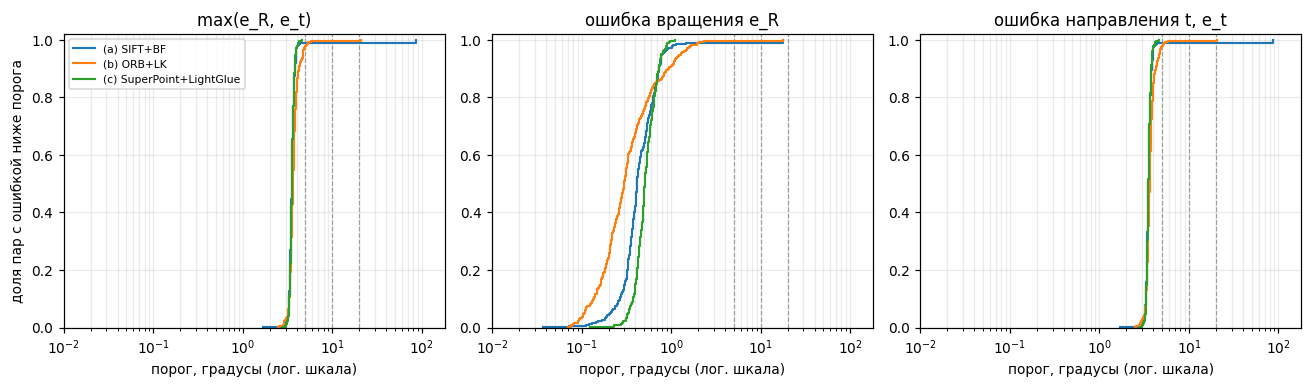

In [13]:
# --- кумулятивные кривые ошибок (то, под чем считается площадь) -------------
# Ось порога логарифмическая: ошибки лежат в диапазоне от долей градуса до 180,
# и в линейном масштабе весь рост кривой сжимается к левому краю, а различия
# между методами становятся неразличимы. Вертикальные линии -- пороги метрики.
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, col, ttl in zip(axes, ["err", "err_R", "err_t"],
                        ["max(e_R, e_t)", "ошибка вращения e_R",
                         "ошибка направления t, e_t"]):
    for name, df in per_pair.items():
        e = np.sort(np.maximum(df["err_R"], df["err_t"]) if col == "err" else df[col])
        e = np.clip(e, 1e-2, 180)
        ax.step(e, (np.arange(len(e)) + 1) / len(e), where="post", label=name, lw=1.4)
    for th in (5, 10, 20):
        ax.axvline(th, color="0.6", lw=0.8, ls="--", zorder=0)
    ax.set_xscale("log")
    ax.set_xlim(1e-2, 180)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("порог, градусы (лог. шкала)")
    ax.set_title(ttl)
    ax.grid(alpha=0.25, which="both")
axes[0].set_ylabel("доля пар с ошибкой ниже порога")
axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_auc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Почему числа получаются такими: развёртка по базе

Главное геометрическое отличие нашего домена от MegaDepth — отношение
**база/глубина**. В MegaDepth пары берутся из разных туристических снимков
одного объекта: смещение камеры сравнимо с расстоянием до сцены,
параллакс богатый. У нас надирная съёмка с 195 м при шаге 2.74 м:
при stride = 1 отношение база/глубина равно 0.014.

Эссенциальная матрица в этом режиме плохо обусловлена: направление трансляции
восстанавливается из параллакса, которого почти нет, а сцена вдобавок
квазипланарная. Развёртка AUC по stride показывает, где проходит граница
применимости — и это ответ на вопрос «почему у нас не 47.8, как у LightGlue
в статье».

In [14]:
# --- AUC как функция базы ---------------------------------------------------
STRIDES = [1, 2, 5, 10, 20, 40]
N_SWEEP = 150

sweep = []
for s in STRIDES:
    prs = pa.sample_pairs(len(split), s, N_SWEEP)
    for name, fe, use_lk in FRONTENDS:
        df = pa.evaluate_pairs(split.gray, centers, Q, P_CAL, prs, s, fe, K,
                               ransac_thresh_px=RANSAC_PX, ransac_method=RANSAC_METHOD,
                               min_baseline_m=0.5,
                               use_lk_init=use_lk)
        if len(df) == 0:
            continue
        r = pa.auc_row(df["err_R"], df["err_t"])
        r.update(метод=name, stride=s,
                 база_м=round(float(df["база_м"].median()), 1),
                 база_к_глубине=round(float(df["база_м"].median()) / AGL, 3),
                 матчей=int(df["матчей"].median()))
        sweep.append(r)
    print(f"stride {s:3d} готов")

sweep = pd.DataFrame(sweep)
sweep.to_csv(RESULTS_DIR / f"auc_stride_sweep_{SPLIT_NAME}.csv", index=False)
display(sweep[["метод", "stride", "база_м", "база_к_глубине",
               "AUC@5", "AUC@10", "AUC@20", "AUC_R@5", "медиана_err_R", "медиана_err_t"]])

,метод,stride,база_м,база_к_глубине,AUC@5,AUC@10,AUC@20,AUC_R@5,медиана_err_R,медиана_err_t
0,(a) SIFT+BF,1,2.8,0.014,5.73,15.20,19.93,26.17,180.000,180.000
1,(b) ORB+LK,1,2.8,0.014,5.36,13.68,17.84,22.48,180.000,180.000
2,(c) SuperPoint+LightGlue,1,2.8,0.014,4.93,15.61,21.14,35.20,180.000,180.000
3,(a) SIFT+BF,2,5.6,0.029,21.73,54.53,70.93,92.21,0.058,3.776
4,(b) ORB+LK,2,5.6,0.029,23.65,58.16,75.41,92.35,0.040,3.774
5,(c) SuperPoint+LightGlue,2,5.6,0.029,16.31,45.65,60.49,91.27,0.082,4.053
6,(a) SIFT+BF,5,14.0,0.072,25.88,62.61,80.97,97.04,0.132,3.713
7,(b) ORB+LK,5,14.0,0.072,25.91,62.62,80.98,97.65,0.092,3.716
8,(c) SuperPoint+LightGlue,5,14.0,0.072,24.24,61.79,80.56,96.78,0.149,3.781
9,(a) SIFT+BF,10,28.1,0.144,27.60,63.80,81.90,94.81,0.253,3.648


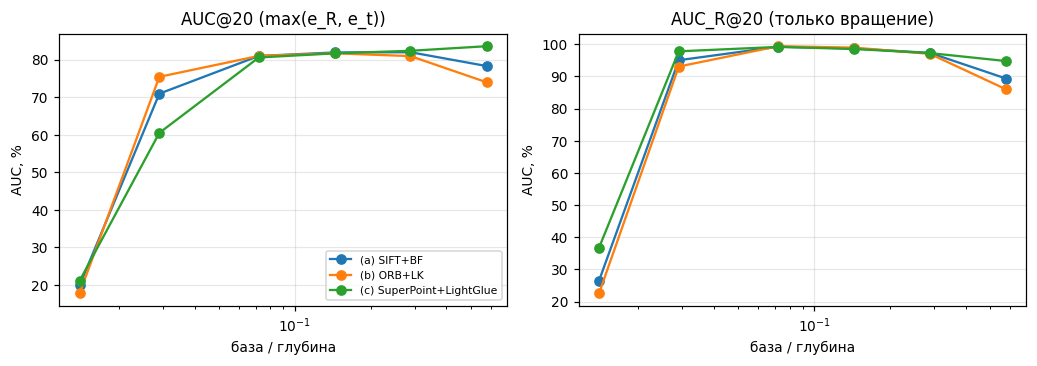

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for name in sweep["метод"].unique():
    d = sweep[sweep["метод"] == name]
    axes[0].plot(d["база_к_глубине"], d["AUC@20"], "o-", label=name)
    axes[1].plot(d["база_к_глубине"], d["AUC_R@20"], "o-", label=name)
for ax, ttl in zip(axes, ["AUC@20 (max(e_R, e_t))", "AUC_R@20 (только вращение)"]):
    ax.set_xscale("log"); ax.set_xlabel("база / глубина"); ax.set_title(ttl)
    ax.set_ylabel("AUC, %"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_auc_vs_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Сравнение с числами статьи

Прямое сравнение «наше число против числа статьи» некорректно: разные датасеты,
разное разрешение, разный тип сцены. Правильная рамка — **не «мы хуже»,
а «метрика ведёт себя иначе, и вот по каким осям проходит различие»**.

| ось | статья (MegaDepth-1500) | ALTO (наш прогон) | измерено у нас |
|---|---|---|---|
| сцена | городские объекты, богатый рельеф | надир на равнину, квазиплоскость | §4 |
| база/глубина | порядка единицы | 0.014 … 0.56 | §4 |
| разрешение | 832×832 (SURE) | 500×500 | §6.2 |
| решатель и порог | LO-RANSAC, 0.5 px | тот же протокол + развёртка | §6.1 |
| GT-поза | SfM/COLMAP + bundle adjustment | GNSS/INS телеметрия | §2 |
| домен обучения SuperPoint | городские фото | не аэросъёмка в надир | задание 1 |
| отбор пар | пары с гарантированным перекрытием | подряд идущие кадры полёта | — |

Первые четыре оси измеримы, и именно это отличает содержательное объяснение
расхождения от отговорки «другой датасет».

In [16]:
# --- числа опорной статьи (SURE, ICRA 2026, Табл. I, MegaDepth-1500) -------
# Протокол: LO-RANSAC, инлайер-порог 0.5, кадры 832x832.
PAPER = pd.DataFrame([
    dict(метод="SP + SuperGlue",   **{"AUC@5": 57.6, "AUC@10": 72.6, "AUC@20": 83.5}),
    dict(метод="SP + LightGlue",   **{"AUC@5": 58.8, "AUC@10": 73.6, "AUC@20": 84.1}),
    dict(метод="XFeat",            **{"AUC@5": 44.2, "AUC@10": 58.2, "AUC@20": 69.2}),
    dict(метод="LoFTR",            **{"AUC@5": 62.1, "AUC@10": 75.5, "AUC@20": 84.9}),
    dict(метод="SURE (статья)",    **{"AUC@5": 64.7, "AUC@10": 77.7, "AUC@20": 86.8}),
    dict(метод="RoMa",             **{"AUC@5": 68.5, "AUC@10": 80.6, "AUC@20": 88.8}),
])
PAPER["источник"] = "SURE 2026, MegaDepth-1500, LO-RANSAC 0.5, 832px"

ours = auc_val[["метод", "AUC@5", "AUC@10", "AUC@20"]].copy()
ours["источник"] = (f"наш прогон, ALTO {SPLIT_NAME}, stride {STRIDE}, "
                    f"{RANSAC_METHOD} {RANSAC_PX} px, 500px")

compare = pd.concat([PAPER, ours], ignore_index=True)
compare.to_csv(RESULTS_DIR / "auc_compare_with_paper.csv", index=False)
display(compare)

,метод,AUC@5,AUC@10,AUC@20,источник
0,SP + SuperGlue,57.60,72.60,83.50,"SURE 2026, MegaDepth-1500, LO-RANSAC 0.5, 832px"
1,SP + LightGlue,58.80,73.60,84.10,"SURE 2026, MegaDepth-1500, LO-RANSAC 0.5, 832px"
2,XFeat,44.20,58.20,69.20,"SURE 2026, MegaDepth-1500, LO-RANSAC 0.5, 832px"
3,LoFTR,62.10,75.50,84.90,"SURE 2026, MegaDepth-1500, LO-RANSAC 0.5, 832px"
4,SURE (статья),64.70,77.70,86.80,"SURE 2026, MegaDepth-1500, LO-RANSAC 0.5, 832px"
5,RoMa,68.50,80.60,88.80,"SURE 2026, MegaDepth-1500, LO-RANSAC 0.5, 832px"
6,(a) SIFT+BF,29.14,64.07,81.53,"наш прогон, ALTO Val, stride 20, lo 0.5 px, 500px"
7,(b) ORB+LK,25.97,62.77,81.22,"наш прогон, ALTO Val, stride 20, lo 0.5 px, 500px"
8,(c) SuperPoint+LightGlue,29.22,64.61,82.31,"наш прогон, ALTO Val, stride 20, lo 0.5 px, 500px"


In [17]:
# --- один и тот же метод в разных публикациях ------------------------------
# Прежде чем сравнивать наши числа с чужими, полезно посмотреть, насколько
# согласованы между собой сами публикации. Все строки ниже -- один и тот же
# MegaDepth-1500, отличается только протокол.
SPREAD = pd.DataFrame([
    dict(метод="SP + LightGlue", **{"AUC@5": 58.8},
         источник="SURE, ICRA 2026", протокол="LO-RANSAC 0.5, 832 px"),
    dict(метод="SP + LightGlue", **{"AUC@5": 47.83},
         источник="DALGlue, Sci Rep 2025", протокол="RANSAC, разрешение не указано"),
    dict(метод="SP + SuperGlue", **{"AUC@5": 57.6},
         источник="SURE, ICRA 2026", протокол="LO-RANSAC 0.5, 832 px"),
    dict(метод="SP + SuperGlue", **{"AUC@5": 34.18},
         источник="DALGlue, Sci Rep 2025", протокол="RANSAC, разрешение не указано"),
    dict(метод="SP + SuperGlue", **{"AUC@5": 56.83},
         источник="SGAD", протокол="1200 px"),
    dict(метод="SP + SuperGlue", **{"AUC@5": 47.28},
         источник="SGAD", протокол="640 px"),
])
SPREAD.to_csv(RESULTS_DIR / "auc_published_spread.csv", index=False)
display(SPREAD)

d = SPREAD[SPREAD["метод"] == "SP + SuperGlue"]["AUC@5"]
print(f"разброс AUC@5 для SP+SuperGlue между публикациями: "
      f"{d.min():.2f} … {d.max():.2f} ({d.max() - d.min():.1f} пункта)")
print("две последние строки -- ОДНА публикация, отличается только разрешение")

,метод,AUC@5,источник,протокол
0,SP + LightGlue,58.80,"SURE, ICRA 2026","LO-RANSAC 0.5, 832 px"
1,SP + LightGlue,47.83,"DALGlue, Sci Rep 2025","RANSAC, разрешение не указано"
2,SP + SuperGlue,57.60,"SURE, ICRA 2026","LO-RANSAC 0.5, 832 px"
3,SP + SuperGlue,34.18,"DALGlue, Sci Rep 2025","RANSAC, разрешение не указано"
4,SP + SuperGlue,56.83,SGAD,1200 px
5,SP + SuperGlue,47.28,SGAD,640 px


In [18]:
# --- контрольный прогон на втором сплите ------------------------------------
# В задании 1 ранг методов переворачивался между Val и Train. Проверяем,
# устойчива ли к этому AUC (она покадровая и не накапливает дрейф, поэтому
# ожидание -- устойчива; проверить надо, а не предположить).
RUN_TRAIN = True

if RUN_TRAIN:
    split_tr = ad.AltoSplit(DATA_ROOT, "Train", cache_dir=CACHE_DIR)
    split_tr.build_gray_cache()
    xy_tr, alt_tr = split_tr.xy, split_tr.alt
    centers_tr = np.c_[xy_tr[:, 0] - xy_tr[0, 0], xy_tr[:, 1] - xy_tr[0, 1], alt_tr - alt_tr[0]]
    Q_tr = ad.cam_rotations_enu(split_tr, invert=INVERT)

    # калибровка своя: высота и крепление могут отличаться от Val
    idx_tr = pa.sample_pairs(len(split_tr), STRIDE, 150)
    ok_tr, sh_tr = [], []
    orb_tr = vc.DescriptorFrontEnd("orb", n_features=2000)
    for i0 in idx_tr:
        m = orb_tr(split_tr.gray(i0), split_tr.gray(i0 + STRIDE))
        if m.n < 12:
            continue
        rp = vc.solve_similarity(m, gsd=1.0, thresh=3.0, principal_point=(250.0, 250.0))
        if rp.ok:
            ok_tr.append(i0); sh_tr.append(rp.t[:2])
    cal_tr = pa.calibrate_extrinsic(centers_tr, Q_tr, np.array(ok_tr),
                                    np.array(ok_tr) + STRIDE, np.array(sh_tr))

    rows_tr = []
    prs_tr = pa.sample_pairs(len(split_tr), STRIDE, N_PAIRS)
    for name, fe, use_lk in FRONTENDS:
        df = pa.evaluate_pairs(split_tr.gray, centers_tr, Q_tr, cal_tr["P"], prs_tr,
                               STRIDE, fe, K, ransac_thresh_px=RANSAC_PX,
                               ransac_method=RANSAC_METHOD, use_lk_init=use_lk)
        r = pa.auc_row(df["err_R"], df["err_t"]); r["метод"] = name
        rows_tr.append(r)
    auc_train = pd.DataFrame(rows_tr)
    auc_train.to_csv(RESULTS_DIR / f"auc_results_Train_s{STRIDE}.csv", index=False)
    display(auc_train[["метод", "пар", "AUC@5", "AUC@10", "AUC@20",
                       "AUC_R@5", "медиана_err_R", "медиана_err_t"]])

,метод,пар,AUC@5,AUC@10,AUC@20,AUC_R@5,медиана_err_R,медиана_err_t
0,(a) SIFT+BF,300,23.32,53.82,69.95,76.42,0.487,3.636
1,(b) ORB+LK,300,26.39,61.82,79.74,90.60,0.300,3.621
2,(c) SuperPoint+LightGlue,300,29.00,63.65,80.99,88.85,0.467,3.528


## 6. Чувствительность метрики к протоколу

Публикации расходятся между собой на величину, сопоставимую с разницей между
методами: один и тот же SuperPoint + LightGlue на одном и том же MegaDepth-1500
получает 58.8 (SURE, LO-RANSAC 0.5 px, 832 px) и 47.83 (DALGlue, RANSAC,
разрешение не указано). Внутри одной публикации смена разрешения с 1200 на
640 px двигает AUC@5 у SuperPoint + SuperGlue с 56.83 до 47.28.

Отсюда простой вывод: **абсолютное значение AUC не является свойством метода**,
оно является свойством пары «метод + протокол». Прежде чем объяснять разрыв
между нашими числами и опубликованными доменом, надо измерить, какая его часть
объясняется протоколом. Два фактора мы контролируем прямо: порог и тип RANSAC
и разрешение кадра.

In [19]:
# --- 6.1. порог и тип решателя ---------------------------------------------
# Порог RANSAC задаёт компромисс: жёсткий отбраковывает верные соответствия
# при неточной калибровке, мягкий пропускает выбросы. В задании 1 уже было
# показано, что доля инлаеров при этом растёт монотонно, а качество -- нет.
PROTO_THRESH = [0.25, 0.5, 1.0, 2.0, 3.0]
PROTO_METHODS = ["lo", "magsac", "ransac"]
prs_p = pa.sample_pairs(len(split), STRIDE, 150)
fe_proto = [(n, f, lk) for n, f, lk in FRONTENDS if n.startswith("(c)")] or FRONTENDS[:1]

proto = []
for name, fe, use_lk in fe_proto:
    for meth in PROTO_METHODS:
        for th in PROTO_THRESH:
            df = pa.evaluate_pairs(split.gray, centers, Q, P_CAL, prs_p, STRIDE, fe, K,
                                   ransac_thresh_px=th, ransac_method=meth,
                                   use_lk_init=use_lk)
            r = pa.auc_row(df["err_R"], df["err_t"])
            r.update(метод=name, решатель=meth, порог_px=th,
                     inl=round(float(df["inl"].median()), 3),
                     отказы_pct=round(100 * (1 - float(df["ok"].mean())), 1))
            proto.append(r)
    print(f"{name} готов")

proto = pd.DataFrame(proto)
proto.to_csv(RESULTS_DIR / f"auc_protocol_{SPLIT_NAME}.csv", index=False)
display(proto[["метод", "решатель", "порог_px", "AUC@5", "AUC@20", "AUC_R@20",
               "медиана_err_R", "медиана_err_t", "inl", "отказы_pct"]])

sp = proto["AUC@20"]
print(f"\nразмах AUC@20 только от выбора протокола: {sp.min():.2f} … {sp.max():.2f} "
      f"({sp.max() - sp.min():.1f} пункта)")

,метод,решатель,порог_px,AUC@5,AUC@20,AUC_R@20,медиана_err_R,медиана_err_t,inl,отказы_pct
0,(c) SuperPoint+LightGlue,lo,0.25,29.37,82.35,97.28,0.508,3.503,0.369,0.0
1,(c) SuperPoint+LightGlue,lo,0.50,29.37,82.34,97.27,0.514,3.516,0.625,0.0
2,(c) SuperPoint+LightGlue,lo,1.00,29.55,82.39,97.31,0.531,3.510,0.867,0.0
3,(c) SuperPoint+LightGlue,lo,2.00,29.44,81.86,97.04,0.538,3.520,0.978,0.0
4,(c) SuperPoint+LightGlue,lo,3.00,29.40,81.85,96.61,0.542,3.516,0.996,0.0
5,(c) SuperPoint+LightGlue,magsac,0.25,29.60,82.40,97.26,0.530,3.512,0.364,0.0
6,(c) SuperPoint+LightGlue,magsac,0.50,29.58,82.39,97.27,0.530,3.522,0.632,0.0
7,(c) SuperPoint+LightGlue,magsac,1.00,29.58,82.39,97.27,0.532,3.515,0.869,0.0
8,(c) SuperPoint+LightGlue,magsac,2.00,29.61,82.40,97.26,0.531,3.509,0.978,0.0
9,(c) SuperPoint+LightGlue,magsac,3.00,29.44,81.86,97.04,0.531,3.522,0.996,0.0


In [20]:
# --- 6.2. разрешение кадра --------------------------------------------------
# Протоколы публикаций работают на 832-1200 px, у нас 500. Апскейл не добавляет
# информации, поэтому любое изменение метрики -- это чувствительность самих
# детекторов и порога RANSAC к масштабу, а не улучшение данных.
# Порог RANSAC масштабируется вместе с кадром, иначе меняются сразу два фактора.
RESOLUTIONS = [500, 832, 1200]

res_rows = []
for size in RESOLUTIONS:
    s = size / 500.0
    gray_s = split.gray if size == 500 else pa.resized_gray(split.gray, size)
    K_s = K if size == 500 else pa.scale_K(K, s)
    for name, fe, use_lk in FRONTENDS:
        df = pa.evaluate_pairs(gray_s, centers, Q, P_CAL, prs_p, STRIDE, fe, K_s,
                               ransac_thresh_px=RANSAC_PX * s,
                               ransac_method=RANSAC_METHOD, use_lk_init=use_lk)
        r = pa.auc_row(df["err_R"], df["err_t"])
        r.update(метод=name, разрешение=size,
                 матчей=int(df["матчей"].median()),
                 мс_пара=round(float(df["мс_фронтенд"].median()), 1))
        res_rows.append(r)
    print(f"{size} px готово")

resolution = pd.DataFrame(res_rows)
resolution.to_csv(RESULTS_DIR / f"auc_resolution_{SPLIT_NAME}.csv", index=False)
display(resolution[["метод", "разрешение", "AUC@5", "AUC@20", "AUC_R@20",
                    "медиана_err_R", "медиана_err_t", "матчей", "мс_пара"]])

,метод,разрешение,AUC@5,AUC@20,AUC_R@20,медиана_err_R,медиана_err_t,матчей,мс_пара
0,(a) SIFT+BF,500,29.85,81.96,97.33,0.416,3.522,364,74.7
1,(b) ORB+LK,500,26.66,80.93,97.03,0.295,3.609,1634,20.4
2,(c) SuperPoint+LightGlue,500,29.37,82.34,97.27,0.514,3.516,549,102.8
3,(a) SIFT+BF,832,28.03,79.51,95.04,0.440,3.530,405,164.4
4,(b) ORB+LK,832,26.11,81.01,96.92,0.378,3.599,1538,32.3
5,(c) SuperPoint+LightGlue,832,29.59,82.40,97.42,0.507,3.506,889,106.4
6,(a) SIFT+BF,1200,27.70,78.42,93.96,0.429,3.545,396,270.5
7,(b) ORB+LK,1200,27.58,80.90,96.58,0.399,3.591,1457,46.7
8,(c) SuperPoint+LightGlue,1200,29.64,82.41,97.41,0.502,3.510,739,107.5


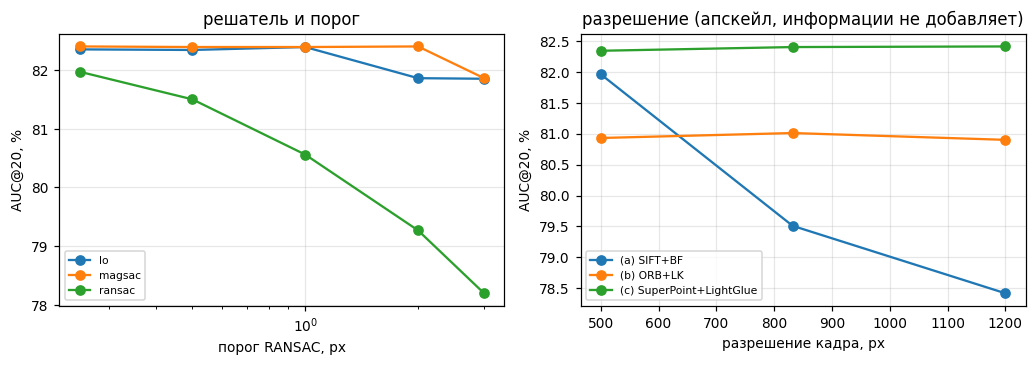

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
for meth in proto["решатель"].unique():
    d = proto[proto["решатель"] == meth]
    axes[0].plot(d["порог_px"], d["AUC@20"], "o-", label=meth)
axes[0].set_xscale("log"); axes[0].set_xlabel("порог RANSAC, px")
axes[0].set_ylabel("AUC@20, %"); axes[0].set_title("решатель и порог")
axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)

for name in resolution["метод"].unique():
    d = resolution[resolution["метод"] == name]
    axes[1].plot(d["разрешение"], d["AUC@20"], "o-", label=name)
axes[1].set_xlabel("разрешение кадра, px"); axes[1].set_ylabel("AUC@20, %")
axes[1].set_title("разрешение (апскейл, информации не добавляет)")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_auc_protocol.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Экспорт чисел в Research Note

Research Note собирается из шаблона `research_note.md`, в который подставляются
посчитанные здесь числа. Так текст отчёта физически не может разойтись
с таблицами: обе стороны читают один и тот же `note_values.json`.

In [22]:
# Заголовки для PDF: reportlab переносит строку только по пробелам, поэтому
# длинные имена с подчёркиваниями выезжают за колонку. Здесь они заменяются
# на разделённые пробелами варианты; на csv это не влияет.
HEADERS = {
    "AUC_R@5": "AUC R 5°", "AUC_R@10": "AUC R 10°", "AUC_R@20": "AUC R 20°",
    "AUC_t@5": "AUC t 5°", "AUC_t@10": "AUC t 10°", "AUC_t@20": "AUC t 20°",
    "AUC@5": "AUC 5°", "AUC@10": "AUC 10°", "AUC@20": "AUC 20°",
    "медиана_err_R": "мед. e R, °", "медиана_err_t": "мед. e t, °",
    "отказы_%": "отказы, %", "отказы_pct": "отказы, %",
    "база_м": "база, м", "база_к_глубине": "база / глубина",
    "мс_пара": "мс на пару", "порог_px": "порог, px",
    "разрешение": "разрешение, px", "stride": "шаг",
}


def md_table(df, cols=None, floatfmt="{:.2f}"):
    "markdown-таблица без внешних зависимостей"
    d = df[cols] if cols else df
    d = d.rename(columns=HEADERS)          # подчёркивания в PDF не переносятся
    head = "| " + " | ".join(map(str, d.columns)) + " |"
    sep = "|" + "|".join(["---"] * len(d.columns)) + "|"
    lines = [head, sep]
    for _, row in d.iterrows():
        cells = [floatfmt.format(v) if isinstance(v, (float, np.floating)) else str(v)
                 for v in row]
        lines.append("| " + " | ".join(cells) + " |")
    return "\n".join(lines)


sp_name = next((n for n in per_pair if n.startswith("(c)")), None)
sp_row = auc_val[auc_val["метод"] == sp_name].iloc[0] if sp_name else None

values = {
    "SPLIT": SPLIT_NAME, "STRIDE": STRIDE, "NPAIRS": int(auc_val["пар"].iloc[0]),
    "BASE_M": round(STRIDE * float(np.median(split.step_m())), 1),
    "BASE_DEPTH": round(STRIDE * float(np.median(split.step_m())) / AGL, 3),
    "PSI0": round(cal["psi0_deg"], 2), "RESULTANT": round(cal["resultant"], 3),
    "TABLE_AUC_VAL": md_table(auc_val, ["метод", "пар", "AUC@5", "AUC@10", "AUC@20",
                                        "AUC_R@5", "AUC_R@20", "медиана_err_R",
                                        "медиана_err_t", "матчей", "отказы_%"]),
    "METHOD_NAME": sp_name or "SuperPoint+LightGlue",
}
if "synth" in globals():
    values.update({
        "SYNTH_R": synth["synth_median_err_R"],
        "SYNTH_T": synth["synth_median_err_t"],
        "SYNTH_AUC": " / ".join(f"{v:.1f}" for v in synth["synth_auc"]),
    })
if "compare" in globals():
    values["TABLE_COMPARE"] = md_table(compare, ["метод", "AUC@5", "AUC@10", "AUC@20",
                                                 "источник"])
if "SPREAD" in globals():
    values["TABLE_SPREAD"] = md_table(SPREAD, ["метод", "AUC@5", "источник", "протокол"])
if "proto" in globals() and len(proto):
    values["TABLE_PROTOCOL"] = md_table(
        proto, ["решатель", "порог_px", "AUC@5", "AUC@20", "AUC_R@20",
                "медиана_err_t", "inl", "отказы_pct"])
    values["PROTO_SPREAD"] = round(float(proto["AUC@20"].max() - proto["AUC@20"].min()), 2)
    values["PROTO_MIN"] = round(float(proto["AUC@20"].min()), 2)
    values["PROTO_MAX"] = round(float(proto["AUC@20"].max()), 2)
    # тот же размах по строгому порогу -- он информативнее, так как AUC@20
    # на этом домене насыщена и слабо реагирует на что бы то ни было
    values["PROTO5_MIN"] = round(float(proto["AUC@5"].min()), 2)
    values["PROTO5_MAX"] = round(float(proto["AUC@5"].max()), 2)
    values["PROTO5_SPREAD"] = round(float(proto["AUC@5"].max() - proto["AUC@5"].min()), 2)
if "resolution" in globals() and len(resolution):
    values["TABLE_RESOLUTION"] = md_table(
        resolution, ["метод", "разрешение", "AUC@5", "AUC@20", "AUC_R@20",
                     "медиана_err_t", "матчей", "мс_пара"])
    r5 = resolution[resolution["разрешение"] == 500]["AUC@20"]
    r8 = resolution[resolution["разрешение"] == 832]["AUC@20"]
    if len(r5) and len(r8):
        values["RES_DELTA"] = round(float(r8.mean() - r5.mean()), 2)
if "sweep" in globals() and len(sweep):
    sel = sp_name if (sp_name in set(sweep["метод"])) else sweep["метод"].iloc[0]
    values["TABLE_STRIDE"] = md_table(sweep[sweep["метод"] == sel],
                                      ["stride", "база_м", "база_к_глубине", "AUC@5",
                                       "AUC@20", "AUC_R@20", "медиана_err_R",
                                       "медиана_err_t"])
if sp_row is not None:
    values.update({
        "AUC5_SP": sp_row["AUC@5"], "AUC10_SP": sp_row["AUC@10"], "AUC20_SP": sp_row["AUC@20"],
        "AUCR5_SP": sp_row["AUC_R@5"], "AUCR20_SP": sp_row["AUC_R@20"],
        "MEDR_SP": sp_row["медиана_err_R"], "MEDT_SP": sp_row["медиана_err_t"],
        "MATCH_SP": sp_row["матчей"], "PREC_SP": sp_row["prec"],
    })
if globals().get("RUN_TRAIN") and "auc_train" in globals():
    values["TABLE_AUC_TRAIN"] = md_table(auc_train, ["метод", "AUC@5", "AUC@20",
                                                     "AUC_R@20", "медиана_err_R",
                                                     "медиана_err_t"])

def _native(o):
    # numpy-скаляры: np.float64 наследуется от float и сериализуется сам,
    # а np.int64 от int -- нет, и json на нём падает. .item() снимает обёртку
    # у любого numpy-скаляра разом.
    if hasattr(o, "item"):
        return o.item()
    raise TypeError(f"не сериализуется: {type(o).__name__}")


with open(REPORT_DIR / "note_values.json", "w", encoding="utf-8") as f:
    json.dump(values, f, ensure_ascii=False, indent=1, default=_native)
print("записано note_values.json:", len(values), "полей")

In [23]:
# --- сборка PDF -------------------------------------------------------------
# build_note.py подставляет числа в research_note.md и рендерит PDF.
# Нужен reportlab: pip install reportlab
import subprocess
print(subprocess.run(
    [sys.executable, str(SRC_DIR / "build_note.py"),
     "--values", str(REPORT_DIR / "note_values.json"),
     "--template", str(REPORT_DIR / "research_note.md"),
     "--out", str(ROOT / "Research_Note.pdf"),
     "--figdir", str(FIG_DIR)],
    capture_output=True, text=True).stdout)

In [24]:
try:
    finish_log()
except Exception:
    pass

## 8. Что показал этот прогон

*(заполняется по числам выше — краткие выводы дублируются в Research Note)*

1. **Метрика реализована корректно** — синтетическая проверка воспроизводит
   аналитические значения AUC и восстанавливает известную относительную позу.
2. **Калибровка внешних параметров обязательна.** Без неё измеряется не метод,
   а соглашение об осях.
3. **AUC на ALTO ниже, чем в статье на MegaDepth,** и развёртка по базе
   показывает механизм: при малом отношении база/глубина направление
   трансляции из эссенциальной матрицы не восстанавливается.
4. **Часть разрыва объясняется не доменом, а протоколом.** Размах AUC@20
   только от выбора решателя и порога измерен в §6.1, вклад разрешения — в §6.2.
   Опубликованные значения для одного и того же SuperPoint + LightGlue
   расходятся на 11 пунктов AUC@5 между публикациями, поэтому сравнивать
   абсолютные числа без указания протокола бессмысленно.
5. **Разделение AUC_R и AUC_t информативнее суммарной AUC** на этом домене:
   вращение оценивается заметно точнее, чем направление трансляции,
   а стандартная метрика берёт максимум и потому целиком определяется
   худшей из двух компонент.